In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('/content/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

In [6]:
df=df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
import matplotlib.pyplot as plt


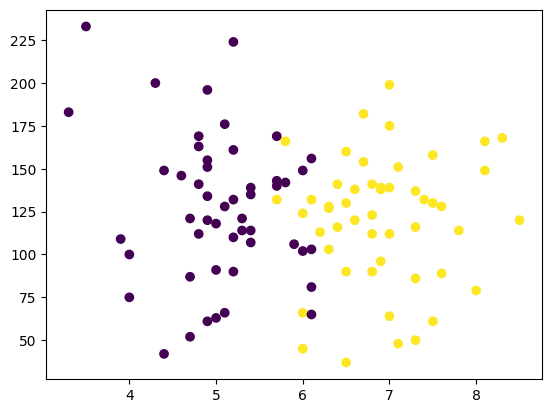

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [12]:
X


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [16]:
X_train

,cgpa,iq
53,8.3,168.0
37,8.1,149.0
44,7.5,61.0
84,5.7,169.0
87,5.7,132.0
...,...,...
43,6.8,141.0
19,5.2,132.0
50,3.5,233.0
31,3.9,109.0


In [18]:
X_test

,cgpa,iq
27,6.0,124.0
36,5.7,140.0
54,6.4,141.0
68,4.0,75.0
81,5.4,107.0
60,6.9,139.0
29,7.0,112.0
80,4.9,196.0
86,5.1,128.0
59,4.8,112.0


In [20]:
y_train

,placement
40,0
42,1
77,1
97,1
71,1
...,...
95,0
44,1
87,1
82,1


In [21]:
y_test

,placement
32,1
68,0
3,1
10,1
85,1
70,1
62,0
6,0
56,0
43,1


In [22]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler();
X_train=scaler.fit_transform(X_train)


In [23]:
X_train

array([[-0.92716262,  0.23362795],
       [ 1.39552312, -0.89682987],
       [ 1.13744693, -1.87655998],
       [ 0.62129454,  1.43944963],
       [ 0.10514215,  0.18338538],
       [ 1.82565011,  0.61044722],
       [-1.35728961,  0.61044722],
       [-0.92716262, -0.11807004],
       [-0.58306103, -0.26879775],
       [-0.66908643, -0.87170859],
       [ 0.44924375, -0.87170859],
       [-1.70139121, -0.62049574],
       [-1.01318802,  0.96214521],
       [-0.15293404,  0.43459823],
       [-1.01318802,  0.40947694],
       [-0.84113723, -0.16831261],
       [-0.49703563,  0.25874923],
       [ 0.01911676,  0.61044722],
       [ 0.44924375,  0.88678136],
       [-2.1315182 ,  2.72063516],
       [-1.18523882,  0.53508337],
       [ 0.79334534,  0.33411309],
       [ 0.01911676, -1.47461942],
       [-0.49703563, -0.26879775],
       [ 0.62129454,  0.73605365],
       [-0.23895944,  1.11287292],
       [ 1.13744693,  0.3089918 ],
       [-0.92716262, -1.60022585],
       [-0.66908643,

In [24]:
X_test=scaler.transform(X_test)

In [26]:
X_test

array([[ 0.87937074,  0.35923437],
       [-1.70139121, -1.24852786],
       [ 1.22347233,  0.18338538],
       [ 0.01911676, -2.00216641],
       [-0.15293404,  1.03750907],
       [ 0.27719295,  0.05777896],
       [ 0.01911676, -0.57025317],
       [-0.23895944,  0.45971951],
       [ 0.10514215, -1.49974071],
       [ 0.70731994,  0.40947694]])

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf=LogisticRegression()

In [35]:
#model training
clf.fit(X_train,y_train)

LogisticRegression()

In [40]:
print(clf.coef_)

[[ 3.3437012  -0.21084847]]


In [37]:
y_pred=clf.predict(X_test)

In [31]:
y_test

,placement
32,1
68,0
3,1
10,1
85,1
70,1
62,0
6,0
56,0
43,1


In [38]:
from sklearn.metrics import accuracy_score


In [39]:
accuracy_score(y_test,y_pred)

0.7

In [41]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

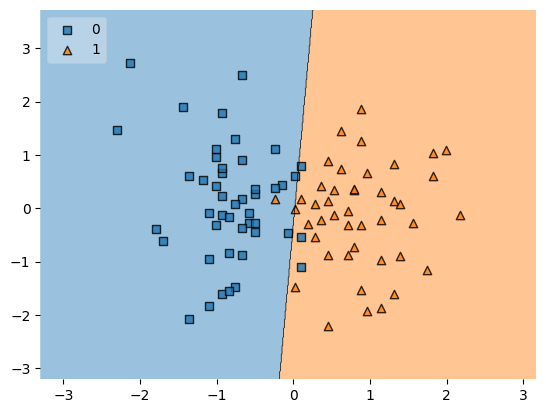

In [42]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [43]:
import pickle

In [44]:
pickle.dump(clf,open('model.pkl','wb'))